# Momentum Crashes Thesis of Tim Hirndorf - University of Mannheim 

In this analysis I will analyse US stock market data according to my base papers Momentum crashes, Daniel & Moskowitz (2016) and Momentum has its moments, Barroso & Santa-Clara (2015)

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats


## Table 1 – Momentum Portfolio Characteristics

Replication of Daniel & Moskowitz (2016), Table 1, using the full available sample from the Kenneth French data library.
Data available under: https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html

### Mathematical definitions

Let $r_{i,t}$ be the **monthly excess return** of portfolio $i$ in month $t$ (i.e. already net of the risk-free rate $r_f$), and let $r_{m,t}$ be the monthly excess market return.

| Symbol | Definition |
|--------|------------|
| $\bar{r} - r_f$ | Annualised mean excess return: $12 \times \bar{r}_i$ (%) |
| $\sigma$ | Annualised volatility: $\sqrt{12} \times \hat{\sigma}_i$ (%) |
| $\alpha$ | CAPM alpha from OLS: $r_{i,t} = \alpha_i + \beta_i r_{m,t} + \varepsilon_{i,t}$, annualised as $12\alpha_i$ (%) |
| $t(\alpha)$ | Newey-West $t$-statistic for $\alpha_i$ (6 lags) |
| $\beta$ | CAPM beta from the same OLS regression |
| SR | Annualised Sharpe ratio: $(\bar{r}_i / \hat{\sigma}_i) \times \sqrt{12}$ |
| sk(m) | Full-period realised skewness of **monthly log returns** $\log(1+r_{i,t}+r_{f,t})$ for deciles & market; for WML: $\log(1+r_{\text{WML},t}+r_{f,t})$ |
| sk(d) | Full-period realised skewness of **daily log returns** (same gross-return convention) |

In [2]:
# 1. Load monthly data
mom_m = pd.read_csv(
    'data/10_Portfolios_Prior_12_2.csv',
    skiprows=11, nrows=1192, index_col=0, header=0
)
mom_m.index = mom_m.index.astype(str).str.strip()
mom_m = mom_m[mom_m.index.str.match(r'^\d{6}$')]
mom_m.index = pd.to_datetime(mom_m.index, format='%Y%m')
mom_m.columns = [f'D{i}' for i in range(1, 11)]
mom_m = mom_m.apply(pd.to_numeric, errors='coerce').replace([-99.99, -999], np.nan) / 100

ff_m = pd.read_csv(
    'data/F-F_Research_Data_Factors.csv',
    skiprows=4, index_col=0
)
ff_m.index = ff_m.index.astype(str).str.strip()
ff_m = ff_m[ff_m.index.str.match(r'^\d{6}$')]
ff_m.index = pd.to_datetime(ff_m.index, format='%Y%m')
ff_m = ff_m.apply(pd.to_numeric, errors='coerce') / 100

data_m = mom_m.join(ff_m, how='inner').sort_index()
data_m['WML'] = data_m['D10'] - data_m['D1']
data_m['Mkt'] = data_m['Mkt-RF'] + data_m['RF']   # gross market return (excess + RF)

print(f'Monthly sample: {data_m.index[0].strftime("%Y-%m")} – {data_m.index[-1].strftime("%Y-%m")}  ({len(data_m)} months)')

# 2. Load daily data
mom_d = pd.read_csv(
    'data/10_Portfolios_Prior_12_2_Daily.csv',
    skiprows=9, index_col=0, header=0
)
mom_d.index = mom_d.index.astype(str).str.strip()
mom_d = mom_d[mom_d.index.str.match(r'^\d{8}$')]
mom_d.index = pd.to_datetime(mom_d.index, format='%Y%m%d')
mom_d.columns = [f'D{i}' for i in range(1, 11)]
mom_d = mom_d.apply(pd.to_numeric, errors='coerce').replace([-99.99, -999], np.nan) / 100

ff_d = pd.read_csv(
    'data/F-F_Research_Data_Factors_daily.csv',
    skiprows=4, index_col=0
)
ff_d.index = ff_d.index.astype(str).str.strip()
ff_d = ff_d[ff_d.index.str.match(r'^\d{8}$')]
ff_d.index = pd.to_datetime(ff_d.index, format='%Y%m%d')
ff_d = ff_d.apply(pd.to_numeric, errors='coerce') / 100

data_d = mom_d.join(ff_d, how='inner').sort_index()
data_d['WML'] = data_d['D10'] - data_d['D1']

print(f'Daily  sample: {data_d.index[0].strftime("%Y-%m-%d")} – {data_d.index[-1].strftime("%Y-%m-%d")}  ({len(data_d)} days)')


Monthly sample: 1927-01 – 2026-02  (1190 months)
Daily  sample: 1926-11-03 – 2026-02-27  (52178 days)


In [3]:
# 3. Helper: Newey-West OLS (alpha, t-stat, beta)

def nw_ols(y, x, lags=6):
    """
    OLS of y on [1, x].  Returns (alpha, t_alpha, beta) with Newey-West
    standard errors (Bartlett kernel, `lags` lags).
    """
    mask = ~(np.isnan(y) | np.isnan(x))
    y, x = y[mask], x[mask]
    n = len(y)
    X = np.column_stack([np.ones(n), x])          # design matrix [1, Mkt-RF]
    b = np.linalg.lstsq(X, y, rcond=None)[0]      # OLS coefficients
    e = y - X @ b                                  # residuals

    # Newey-West covariance
    S = X.T @ np.diag(e**2) @ X                   # HC0 sandwich
    for lag in range(1, lags + 1):
        Gamma = X[lag:].T @ np.diag(e[lag:] * e[:-lag]) @ X[:-lag]
        w = 1 - lag / (lags + 1)                  # Bartlett weight
        S += w * (Gamma + Gamma.T)
    V = np.linalg.inv(X.T @ X) @ S @ np.linalg.inv(X.T @ X)

    alpha, beta = b
    t_alpha = alpha / np.sqrt(V[0, 0])
    return alpha, t_alpha, beta


# 4. Build Table 1
portfolios = [f'D{i}' for i in range(1, 11)] + ['WML', 'Mkt-RF']
col_labels = [str(i) for i in range(1, 11)] + ['WML', 'Market']

rows = {stat: [] for stat in ['r-rf', 'sigma', 'alpha', 't_alpha', 'beta', 'SR', 'sk_m', 'sk_d']}

mkt_excess = data_m['Mkt-RF'].dropna().values

for port in portfolios:
    # monthly excess returns
    if port == 'Mkt-RF':
        s_m = data_m['Mkt-RF'].dropna()
    else:
        s_m = data_m[port].dropna()

    mu   = s_m.mean()
    sig  = s_m.std(ddof=1)

    rows['r-rf'].append(mu  * 12 * 100)
    rows['sigma'].append(sig * np.sqrt(12) * 100)
    rows['SR'].append((mu / sig) * np.sqrt(12))

    # CAPM regression
    aligned = data_m[[port, 'Mkt-RF']].dropna() if port != 'Mkt-RF' else None
    if port == 'Mkt-RF':
        # Market vs itself: alpha=0, beta=1 by construction
        rows['alpha'].append(0.0)
        rows['t_alpha'].append(0.0)
        rows['beta'].append(1.0)
    else:
        a, ta, b = nw_ols(aligned[port].values, aligned['Mkt-RF'].values, lags=6)
        rows['alpha'].append(a * 12 * 100)
        rows['t_alpha'].append(ta)
        rows['beta'].append(b)

    # Monthly log-return skewness
    # For deciles & market: log(1 + excess_return + RF)
    # For WML:              log(1 + WML_excess + RF)  (same formula)
    rf_m = data_m['RF']
    if port == 'Mkt-RF':
        gross_log_m = np.log1p(data_m['Mkt-RF'] + rf_m).dropna()
    else:
        gross_log_m = np.log1p(data_m[port] + rf_m).dropna()
    rows['sk_m'].append(gross_log_m.skew())

    # Daily log-return skewness
    rf_d = data_d['RF']
    if port == 'Mkt-RF':
        gross_log_d = np.log1p(data_d['Mkt-RF'] + rf_d).dropna()
    elif port == 'WML':
        gross_log_d = np.log1p(data_d['WML'] + rf_d).dropna()
    else:
        gross_log_d = np.log1p(data_d[port] + rf_d).dropna()
    rows['sk_d'].append(gross_log_d.skew())


# 5. Format and display
stat_labels = [
    r'$\bar{r} - r_f$',
    r'$\sigma$',
    r'$\alpha$',
    r'$t(\alpha)$',
    r'$\beta$',
    'SR',
    'sk(m)',
    'sk(d)',
]

table = pd.DataFrame(rows, index=col_labels).T
table.index = stat_labels

def fmt(val, row):
    if row in [r'$\bar{r} - r_f$', r'$\sigma$', r'$\alpha$']:
        return f'{val:.1f}'
    elif row == r'$t(\alpha)$':
        return f'({val:.1f})' if val != 0.0 else '(0)'
    elif row == r'$\beta$':
        return f'{val:.2f}'
    elif row == 'SR':
        return f'{val:.2f}'
    else:  # skewness
        return f'{val:.2f}'

formatted = table.apply(lambda col: [fmt(v, idx) for idx, v in zip(table.index, col)])
formatted.index = stat_labels
formatted.columns = col_labels

start_yr = data_m.index[0].strftime('%Y:%m')
end_yr   = data_m.index[-1].strftime('%Y:%m')

print(f'Table 1 – Momentum portfolio characteristics, {start_yr}–{end_yr}')
formatted


Table 1 – Momentum portfolio characteristics, 1927:01–2026:02


,1,2,3,4,5,6,7,8,9,10,WML,Market
$\bar{r} - r_f$,4.5,9.0,9.6,10.9,11.2,11.7,12.4,13.5,14.0,18.0,13.5,8.2
$\sigma$,33.9,27.9,23.9,21.8,20.2,19.8,18.7,18.3,19.2,22.2,27.4,18.4
$\alpha$,-8.4,-2.0,-0.0,1.9,2.7,3.3,4.4,5.8,6.2,9.6,18.0,0.0
$t(\alpha)$,(-5.4),(-1.6),(-0.0),(2.1),(3.7),(5.5),(6.8),(9.0),(7.8),(7.8),(8.3),(0)
$\beta$,1.56,1.34,1.17,1.09,1.03,1.02,0.96,0.93,0.95,1.02,-0.54,1.00
SR,0.13,0.32,0.40,0.50,0.55,0.59,0.66,0.74,0.73,0.81,0.49,0.45
sk(m),0.03,-0.11,-0.21,-0.02,-0.06,-0.34,-0.55,-0.54,-0.81,-0.87,-5.81,-0.55
sk(d),0.38,0.41,0.19,0.16,0.07,-0.21,-0.33,-0.62,-0.58,-0.73,-1.62,-0.46


## Figure 1 – Winners and Losers

Cumulative dollar value of a $1 investment (log scale) in four assets from the start of the sample:
1. **Risk-free** – compounded monthly T-bill rate
2. **Market** – CRSP value-weighted index (Mkt-RF + RF)
3. **Past losers (D1)** – bottom momentum decile gross return (D1 + RF)
4. **Past winners (D10)** – top momentum decile gross return (D10 + RF)

Shaded bands highlight four major momentum crash episodes:
- **1932-07 – 1933-05** (blue): Great Depression reversal — WML −78% (Aug 1932) and −63% (Jul 1932), the two worst months on record
- **2001-01 – 2001-01** (purple): Tech-bubble reversal — WML −42% in Jan 2001 as past losers (internet stocks) rebounded sharply
- **2009-03 – 2009-05** (orange): GFC reversal — WML −39%, −45%, −21% as the market bottomed and losers bounced
- **2020-02 – 2020-06** (green): COVID reversal — WML −32% in Apr 2020 as beaten-down stocks recovered fastest


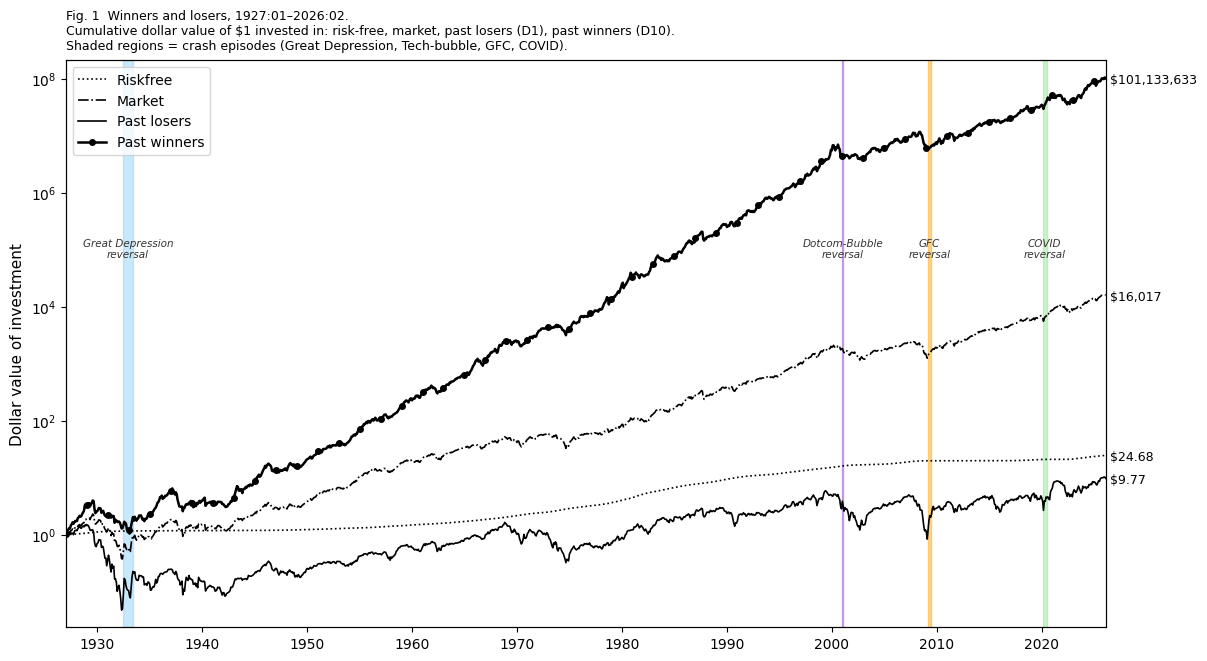

In [4]:
# Figure 1: Winners and Losers (cumulative wealth, log scale)

# Sorting the data chronologically to fix timeline for plot
data_m = data_m.sort_index()

# Gross monthly returns (total return, not excess)
gross_rf  = 1 + data_m["RF"]
gross_mkt = 1 + data_m["Mkt-RF"] + data_m["RF"]
gross_d1  = 1 + data_m["D1"]  + data_m["RF"]
gross_d10 = 1 + data_m["D10"] + data_m["RF"]

# Cumulative wealth starting at $1
cum_rf  = gross_rf.cumprod()
cum_mkt = gross_mkt.cumprod()
cum_d1  = gross_d1.cumprod()
cum_d10 = gross_d10.cumprod()

# Four crash episodes with shaded bands
crash_periods = [
    ("1932-07", "1933-05", "Great Depression\nreversal"),
    ("2001-01", "2001-01", "Dotcom-Bubble\nreversal"),
    ("2009-03", "2009-05", "GFC\nreversal"),
    ("2020-02", "2020-06", "COVID\nreversal"),
]

# Plot
fig, ax = plt.subplots(figsize=(13, 7))

ax.semilogy(cum_rf.index,  cum_rf.values,  "k:",   lw=1.2, label="Riskfree")
ax.semilogy(cum_mkt.index, cum_mkt.values, "k-.", lw=1.2, label="Market")
ax.semilogy(cum_d1.index,  cum_d1.values,  "k-",  lw=1.2, label="Past losers")
ax.semilogy(cum_d10.index, cum_d10.values, "k-",  lw=1.8,
            marker="o", markevery=24, markersize=4, label="Past winners")

# Crash shading + period labels
shade_colors = ["#87cefa", "#9d4ccc", "#ffa500", "#88e788"]
for (start, end, label), color in zip(crash_periods, shade_colors):
    t0 = pd.Timestamp(start)
    t1 = pd.Timestamp(end) + pd.offsets.MonthEnd(1)
    ax.axvspan(t0, t1, alpha=0.45, color=color, zorder=0)
    mid = t0 + (t1 - t0) / 2
    ax.text(mid, 160000, label, ha="center", va="top", fontsize=7.5,
            color="#333333", style="italic")

# Right axis: final dollar values
final_vals = [
    (cum_d10.iloc[-1], f"${cum_d10.iloc[-1]:,.0f}"),
    (cum_mkt.iloc[-1], f"${cum_mkt.iloc[-1]:,.0f}"),
    (cum_rf.iloc[-1],  f"${cum_rf.iloc[-1]:.2f}"),
    (cum_d1.iloc[-1],  f"${cum_d1.iloc[-1]:.2f}"),
]
right_ax = ax.twinx()
right_ax.set_yscale("log")
# Set y-limits from data (ax.get_ylim() is unreliable before draw)
all_vals = np.concatenate([cum_rf.values, cum_mkt.values, cum_d1.dropna().values, cum_d10.values])
ymin = all_vals[all_vals > 0].min() * 0.5
ymax = all_vals.max() * 2.0
ax.set_ylim(ymin, ymax)
right_ax.set_ylim(ymin, ymax)
right_ax.set_yticks([v for v, _ in final_vals])
right_ax.set_yticklabels([lbl for _, lbl in final_vals], fontsize=9)
right_ax.tick_params(axis="y", length=0)

# Axes formatting
ax.set_ylabel("Dollar value of investment", fontsize=11)
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlim(cum_rf.index[0], cum_rf.index[-1])
ax.legend(loc="upper left", fontsize=10, frameon=True)

start_label = data_m.index[0].strftime("%Y:%m")
end_label   = data_m.index[-1].strftime("%Y:%m")
ax.set_title(
    f'Fig. 1  Winners and losers, {start_label}\u2013{end_label}.\n'
    'Cumulative dollar value of $1 invested in: risk-free, market, past losers (D1), past winners (D10).\n'
    "Shaded regions = crash episodes (Great Depression, Tech-bubble, GFC, COVID).",
    fontsize=9, loc='left', pad=8
)

fig.subplots_adjust(left=0.07, right=0.87, top=0.88, bottom=0.07)
plt.show()

## Table 2 – Worst Monthly Momentum Returns

The 15 worst monthly returns to the WML momentum portfolio over the full sample.
Also tabulated are:
- **MKT-2y**: cumulative market return over the 24 months *prior* to the portfolio formation date
  (i.e. $\prod_{s=t-24}^{t-1}(1+r_{m,s}) - 1$)
- **Mkt*: contemporaneous total market return in month $ (Mkt-RF + RF)

All numbers in percent. Period markers:
-  July 1932 – September 1939 (Great Depression reversal)
-  April 2009 – August 2009 (GFC reversal)
-  January 2001 – November 2002 (Dotcom-bubble reversal)
-  February 2020 – June 2020 (COVID reversal)


In [5]:
# Table 2: 15 worst WML months

# Two-year cumulative market return ending the month before t
mkt_gross = 1 + data_m['Mkt-RF'] + data_m['RF']
data_m['MKT-2y'] = mkt_gross.rolling(24).apply(np.prod, raw=True).shift(1) - 1
data_m['Mkt_t']  = data_m['Mkt-RF'] + data_m['RF']   # contemporaneous total market return

# 15 worst WML months, sorted ascending
worst15_idx = data_m['WML'].nsmallest(15).sort_values().index

# Period markers
def marker(dt):
    if pd.Timestamp('1932-07') <= dt <= pd.Timestamp('1939-09'): return '*'
    if pd.Timestamp('2009-04') <= dt <= pd.Timestamp('2009-08'): return '†'  # †
    if pd.Timestamp('2001-01') <= dt <= pd.Timestamp('2002-11'): return '‡'  # ‡
    if pd.Timestamp('2020-02') <= dt <= pd.Timestamp('2020-06'): return '§'  # §
    return ''

rows = []
for rank, dt in enumerate(worst15_idx, 1):
    rows.append({
        'Rank':    rank,
        'Month':   dt.strftime('%Y:%m') + marker(dt),
        'WML_t':   data_m.loc[dt, 'WML']    * 100,
        'MKT-2y':  data_m.loc[dt, 'MKT-2y'] * 100,
        'Mkt_t':   data_m.loc[dt, 'Mkt_t']  * 100,
        'D1_t':    data_m.loc[dt, 'D1']     * 100,
        'D10_t':   data_m.loc[dt, 'D10']    * 100,
    })

tab2 = pd.DataFrame(rows).set_index('Rank')

start_yr = data_m.index[0].strftime('%Y:%m')
end_yr   = data_m.index[-1].strftime('%Y:%m')
print(f'Table 2 – Worst monthly momentum returns, {start_yr}–{end_yr}')

tab2.style.format({
    'WML_t':  '{:.2f}',
    'MKT-2y': '{:.2f}',
    'Mkt_t':  '{:.2f}',
    'D1_t':   '{:.2f}',
    'D10_t':  '{:.2f}',
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'right')]},
    {'selector': 'td', 'props': [('text-align', 'right')]},
]).set_caption(
    f'Table 2: 15 worst WML months, {start_yr}–{end_yr}. '
    '* = Great Depression (1932:07–1939:09), '
    '† = GFC (2009:04–2009:08), '
    '‡ = Dotcom (2001:01–2002:11), '
    '§ = COVID (2020:02–2020:06). All values in %.'
)


Table 2 – Worst monthly momentum returns, 1927:01–2026:02


,Month,WML_t,MKT-2y,Mkt_t,D1_t,D10_t
Rank,,,,,,
1,1932:08*,-78.04,-67.57,37.15,93.84,15.80
2,1932:07*,-63.04,-74.69,33.63,74.94,11.90
3,2009:04†,-45.32,-40.49,10.18,45.20,-0.12
4,1939:09*,-44.36,-21.87,16.90,52.28,7.92
5,2001:01‡,-41.71,10.72,3.79,35.72,-5.99
6,2009:03,-39.18,-44.79,9.03,44.65,5.47
7,1938:06*,-33.47,-28.17,23.89,43.58,10.11
8,2020:04§,-31.69,-0.74,13.60,46.12,14.43
9,1933:04*,-31.53,-58.97,38.91,60.21,28.68


## Table 3 – Market Timing Regression

Replication of Daniel & Moskowitz (2016), Table 3. The dependent variable is the monthly WML excess return.
The full regression model is:

$$R_{WML,t} = \hat{\alpha}_0 + \hat{\alpha}_B I_{B,t-1} + \hat{\beta}_0 \tilde{R}^e_{m,t} + \hat{\beta}_B (I_{B,t-1} \cdot \tilde{R}^e_{m,t}) + \hat{\beta}_{B,U} (I_{B,t-1} \cdot I_{U,t} \cdot \tilde{R}^e_{m,t}) + \epsilon_t$$

### Variable definitions

| Symbol | Definition |
| :--- | :--- |
| $I_{B,t-1}$ | **Bear-market indicator:** equals 1 if the cumulative market return over the 24 months *prior* to $t$ is negative, i.e. $\prod_{s=t-24}^{t-1}(1 + R^e_{m,s} + R_{f,s}) - 1 < 0$ |
| $\tilde{R}^e_{m,t}$ | Contemporaneous **excess market return** $R^e_{m,t} = R_{m,t} - R_{f,t}$ |
| $I_{U,t}$ | **Up-market indicator:** equals 1 if $R^e_{m,t} > 0$ |
| $\hat{\alpha}_0$ | Unconditional WML intercept ($\times 100$, in % per month) |
| $\hat{\alpha}_B$ | Incremental intercept in bear markets ($\times 100$, in % per month) |
| $\hat{\beta}_0$ | Unconditional market beta |
| $\hat{\beta}_B$ | Incremental beta in bear markets |
| $\hat{\beta}_{B,U}$ | Additional incremental beta in bear + up markets |

The four specifications include progressively more interaction terms. All $t$-statistics use Newey-West standard errors with 6 lags.


In [6]:
# Table 3: Market timing regression

# Construct regression variables
# Bear-market indicator: I_B,t-1 = 1 if 2-year cumulative market return < 0
mkt_gross_2y = 1 + data_m['Mkt-RF'] + data_m['RF']
mkt_2y       = mkt_gross_2y.rolling(24).apply(np.prod, raw=True).shift(1) - 1
data_m['I_B']  = (mkt_2y < 0).astype(float)          # I_{B,t-1}
data_m['Rm']   = data_m['Mkt-RF']                     # R^e_{m,t}
data_m['I_U']  = (data_m['Rm'] > 0).astype(float)    # I_{U,t}

# Interaction terms
data_m['I_B_Rm']       = data_m['I_B'] * data_m['Rm']                        # I_{B,t-1} * R^e_{m,t}
data_m['I_B_I_U_Rm']   = data_m['I_B'] * data_m['I_U'] * data_m['Rm']       # I_{B,t-1} * I_{U,t} * R^e_{m,t}

# NW OLS helper (multi-regressor)
def nw_ols_multi(y_col, x_cols, data, lags=6):
    """
    OLS of y on [1, x_cols] with Newey-West SEs (Bartlett, `lags` lags).
    Returns (coefficients, t-statistics, adj-R2).
    """
    df = data[[y_col] + x_cols].dropna()
    y  = df[y_col].values
    X  = np.column_stack([np.ones(len(df)), df[x_cols].values])
    b  = np.linalg.lstsq(X, y, rcond=None)[0]
    e  = y - X @ b
    n, k = len(y), X.shape[1] - 1
    S  = X.T @ np.diag(e**2) @ X
    for lag in range(1, lags + 1):
        G = X[lag:].T @ np.diag(e[lag:] * e[:-lag]) @ X[:-lag]
        S += (1 - lag / (lags + 1)) * (G + G.T)
    V      = np.linalg.inv(X.T @ X) @ S @ np.linalg.inv(X.T @ X)
    t_stat = b / np.sqrt(np.diag(V))
    ss_res = np.sum(e**2)
    ss_tot = np.sum((y - y.mean())**2)
    r2_adj = 1 - (ss_res / (n - k - 1)) / (ss_tot / (n - 1))
    return b, t_stat, r2_adj

# Run four specifications
specs = [
    # (label, x_cols)
    ('(1)', ['Rm']),
    ('(2)', ['I_B', 'Rm', 'I_B_Rm']),
    ('(3)', ['I_B', 'Rm', 'I_B_Rm', 'I_B_I_U_Rm']),
    ('(4)', ['Rm', 'I_B_Rm', 'I_B_I_U_Rm']),
]

results = {}
for name, xcols in specs:
    b, t, r2 = nw_ols_multi('WML', xcols, data_m, lags=6)
    results[name] = {'b': b, 't': t, 'r2': r2, 'xcols': xcols}

# Format into Table 3 (coef row + t-stat row per variable)
# Columns map: intercept=a0, I_B=aB, Rm=b0, I_B_Rm=bB, I_B_I_U_Rm=bBU
coef_map = [
    ('intercept', r'$\hat{\alpha}_0$',    r'$1$',                                              True),
    ('I_B',       r'$\hat{\alpha}_B$',    r'$I_{B,t-1}$',                                      True),
    ('Rm',        r'$\hat{\beta}_0$',     r'$\tilde{R}^e_{m,t}$',                              False),
    ('I_B_Rm',    r'$\hat{\beta}_B$',     r'$I_{B,t-1}\cdot\tilde{R}^e_{m,t}$',              False),
    ('I_B_I_U_Rm',r'$\hat{\beta}_{B,U}$', r'$I_{B,t-1}\cdot I_{U,t}\cdot\tilde{R}^e_{m,t}$', False),
]

spec_names = list(results.keys())
coef_rows  = []   # coefficient values
tstat_rows = []   # t-statistics
index_labels = [] # row index: (coef_label, sub-row)

for var_key, coef_label, var_label, scale in coef_map:
    coef_row  = {}
    tstat_row = {}
    for spec_name, res in results.items():
        xcols = res['xcols']
        b, t  = res['b'], res['t']
        if var_key == 'intercept':
            idx = 0
        elif var_key in xcols:
            idx = xcols.index(var_key) + 1
        else:
            coef_row[spec_name]  = ''
            tstat_row[spec_name] = ''
            continue
        val  = b[idx] * 100 if scale else b[idx]
        tval = t[idx]
        coef_row[spec_name]  = f'{val:.3f}'
        tstat_row[spec_name] = f'({tval:.1f})'
    coef_rows.append(coef_row)
    tstat_rows.append(tstat_row)
    index_labels.append((coef_label, 'coef'))
    index_labels.append((coef_label, 't-stat'))

# Interleave coef and t-stat rows
all_rows = []
for c, t in zip(coef_rows, tstat_rows):
    all_rows.append(c)
    all_rows.append(t)

# R2 adj row (single row, no t-stat)
r2_row = {s: f"{results[s]['r2']:.3f}" for s in spec_names}
index_labels.append((r'$R^2_{adj}$', ''))
all_rows.append(r2_row)

idx = pd.MultiIndex.from_tuples(index_labels, names=['Coefficient', ''])
tab3 = pd.DataFrame(all_rows, index=idx)

start_yr = data_m.index[0].strftime('%Y:%m')
end_yr   = data_m.index[-1].strftime('%Y:%m')
print(f'Table 3 – Market timing regression, {start_yr}\u2013{end_yr}')
print('alpha_0 and alpha_B x100 (% per month). t-stats (NW, 6 lags) in parentheses.')
tab3


Table 3 – Market timing regression, 1927:01–2026:02
alpha_0 and alpha_B x100 (% per month). t-stats (NW, 6 lags) in parentheses.


(1)     (2)     (3)     (4)
Coefficient                                               
$\hat{\alpha}_0$    coef     1.498   1.595   1.595   1.633
                    t-stat   (8.3)   (8.5)   (8.5)   (8.6)
$\hat{\alpha}_B$    coef            -1.856   0.448        
                    t-stat          (-2.8)   (0.4)        
$\hat{\beta}_0$     coef    -0.542  -0.067  -0.067  -0.068
                    t-stat  (-4.0)  (-1.1)  (-1.1)  (-1.1)
$\hat{\beta}_B$     coef            -1.054  -0.629  -0.667
                    t-stat          (-5.8)  (-4.0)  (-5.3)
$\hat{\beta}_{B,U}$ coef                    -0.725  -0.656
                    t-stat                  (-2.2)  (-3.0)
$R^2_{adj}$                  0.132   0.270   0.281   0.282

## Table 4 - Momentum Portfolio Optionality

Replication of Daniel & Moskowitz (2016), Table 4. Each column runs a time-series regression of the **monthly excess return** of a momentum decile portfolio (or WML) on the excess market return and indicator variables.

**Panel A - Optionality in bear markets:**

$$\tilde{R}^e_{i,t} = \bigl[{\alpha}_0 + {\alpha}_B I_{B,t-1}\bigr] + \bigl[{\beta}_0 + I_{B,t-1}({\beta}_B + \tilde{I}_{U,t}{\beta}_{B,U})\bigr]\tilde{R}^e_{m,t} + \tilde{\epsilon}_t$$

**Panel B - Optionality in bull markets:**

$$\tilde{R}^e_{i,t} = \bigl[{\alpha}_0 + {\alpha}_L I_{L,t-1}\bigr] + \bigl[{\beta}_0 + I_{L,t-1}({\beta}_L + \tilde{I}_{U,t}{\beta}_{L,U})\bigr]\tilde{R}^e_{m,t} + \tilde{\epsilon}_t$$

### Variable definitions

| Symbol | Definition |
| :--- | :--- |
| $I_{B,t-1}$ | **Bear indicator:** 1 if 24-month cumulative market return before $t$ is negative |
| $I_{L,t-1}$ | **Bull indicator:** $1 - I_{B,t-1}$ |
| $\tilde{R}^e_{m,t}$ | Contemporaneous excess market return |
| $I_{U,t}$ | **Up-market indicator:** 1 if $R^e_{m,t} > 0$ |
| $\hat{\alpha}_0, \hat{\alpha}_B, \hat{\alpha}_L$ | Intercepts (x100, % per month) |
| $\hat{\beta}_0$ | Unconditional market beta |
| $\hat{\beta}_B, \hat{\beta}_{B,U}$ | Incremental betas in bear / bear+up markets |
| $\hat{\beta}_L, \hat{\beta}_{L,U}$ | Incremental betas in bull / bull+up markets |

All $t$-statistics use Newey-West standard errors with 6 lags.

In [7]:
# Table 4: Momentum portfolio optionality

# Indicators and interaction terms
mkt_gross_t4 = 1 + data_m['Mkt-RF'] + data_m['RF']
mkt_2y_t4    = mkt_gross_t4.rolling(24).apply(np.prod, raw=True).shift(1) - 1
data_m['I_B_t4']  = (mkt_2y_t4 < 0).astype(float)   # bear: 2y cum mkt return < 0
data_m['I_L_t4']  = 1 - data_m['I_B_t4']             # bull: 1 - I_B
data_m['Rm_t4']   = data_m['Mkt-RF']                  # excess market return
data_m['I_U_t4']  = (data_m['Rm_t4'] > 0).astype(float)  # up-market

# Panel A regressors: I_B, Rm, I_B*Rm, I_B*I_U*Rm
data_m['I_B_Rm_t4']     = data_m['I_B_t4'] * data_m['Rm_t4']
data_m['I_B_IU_Rm_t4']  = data_m['I_B_t4'] * data_m['I_U_t4'] * data_m['Rm_t4']

# Panel B regressors: I_L, Rm, I_L*Rm, I_L*I_U*Rm
data_m['I_L_Rm_t4']     = data_m['I_L_t4'] * data_m['Rm_t4']
data_m['I_L_IU_Rm_t4']  = data_m['I_L_t4'] * data_m['I_U_t4'] * data_m['Rm_t4']

# NW OLS (multi-regressor, returns b and t-stat arrays)
def nw_ols_t4(y_arr, X_arr, lags=6):
    mask = ~(np.isnan(y_arr) | np.any(np.isnan(X_arr), axis=1))
    y, X = y_arr[mask], X_arr[mask]
    n = len(y)
    Xd = np.column_stack([np.ones(n), X])
    b  = np.linalg.lstsq(Xd, y, rcond=None)[0]
    e  = y - Xd @ b
    S  = Xd.T @ np.diag(e**2) @ Xd
    for lag in range(1, lags + 1):
        G = Xd[lag:].T @ np.diag(e[lag:] * e[:-lag]) @ Xd[:-lag]
        S += (1 - lag / (lags + 1)) * (G + G.T)
    V = np.linalg.inv(Xd.T @ Xd) @ S @ np.linalg.inv(Xd.T @ Xd)
    return b, b / np.sqrt(np.diag(V))

# Run regressions for all portfolios
portfolios_t4 = [f'D{i}' for i in range(1, 11)] + ['WML']
col_labels_t4 = [str(i) for i in range(1, 11)] + ['WML']

X_A = data_m[['I_B_t4', 'Rm_t4', 'I_B_Rm_t4', 'I_B_IU_Rm_t4']].values
X_B = data_m[['I_L_t4', 'Rm_t4', 'I_L_Rm_t4', 'I_L_IU_Rm_t4']].values

# coef index: 0=intercept, 1=I_B/I_L, 2=Rm, 3=I_B*Rm/I_L*Rm, 4=I_B*I_U*Rm/I_L*I_U*Rm
# scale *100 for intercepts (indices 0,1)
panels = {
    'Panel A: Optionality in bear markets': (
        X_A,
        [r'$\hat{\alpha}_0$', r'$\hat{\alpha}_B$',
         r'$\hat{\beta}_0$',  r'$\hat{\beta}_B$', r'$\hat{\beta}_{B,U}$'],
        [True, True, False, False, False]
    ),
    'Panel B: Optionality in bull markets': (
        X_B,
        [r'$\hat{\alpha}_0$', r'$\hat{\alpha}_L$',
         r'$\hat{\beta}_0$',  r'$\hat{\beta}_L$', r'$\hat{\beta}_{L,U}$'],
        [True, True, False, False, False]
    ),
}

# Build and display each panel
start_yr = data_m.index[0].strftime('%Y:%m')
end_yr   = data_m.index[-1].strftime('%Y:%m')
print(f'Table 4 – Momentum portfolio optionality, {start_yr}\u2013{end_yr}')
print('Intercepts x100 (% per month). t-stats (NW, 6 lags) in parentheses.')

for panel_title, (X_mat, coef_labels, scale_flags) in panels.items():
    # Collect results
    bs = {}; ts = {}
    for port in portfolios_t4:
        b, t = nw_ols_t4(data_m[port].values, X_mat)
        bs[port] = b; ts[port] = t

    # Build alternating coef / t-stat rows
    all_rows = []; idx_labels = []
    for ci, (clabel, sc) in enumerate(zip(coef_labels, scale_flags)):
        coef_row  = {cl: f"{bs[p][ci]*100 if sc else bs[p][ci]:.3f}"
                     for p, cl in zip(portfolios_t4, col_labels_t4)}
        tstat_row = {cl: f"({ts[p][ci]:.1f})"
                     for p, cl in zip(portfolios_t4, col_labels_t4)}
        all_rows += [coef_row, tstat_row]
        idx_labels += [(clabel, 'coef'), (clabel, 't-stat')]

    midx = pd.MultiIndex.from_tuples(idx_labels, names=['Coefficient', ''])
    panel_df = pd.DataFrame(all_rows, index=midx)

    print(f'\n{panel_title}')
    display(panel_df)


Table 4 – Momentum portfolio optionality, 1927:01–2026:02
Intercepts x100 (% per month). t-stats (NW, 6 lags) in parentheses.

Panel A: Optionality in bear markets


1       2       3       4       5       6  \
Coefficient                                                                  
$\hat{\alpha}_0$    coef    -0.831  -0.245   0.023   0.178   0.288   0.312   
                    t-stat  (-6.2)  (-2.2)   (0.3)   (2.2)   (4.9)   (6.6)   
$\hat{\alpha}_B$    coef    -0.099  -0.071  -0.261  -0.644  -0.867  -0.399   
                    t-stat  (-0.1)  (-0.1)  (-0.5)  (-2.0)  (-1.9)  (-1.7)   
$\hat{\beta}_0$     coef     1.306   1.103   0.982   0.946   0.916   0.945   
                    t-stat  (28.6)  (27.8)  (30.2)  (34.9)  (44.3)  (52.3)   
$\hat{\beta}_B$     coef     0.263   0.303   0.304   0.153   0.115   0.103   
                    t-stat   (2.4)   (3.3)   (5.3)   (2.6)   (1.8)   (2.0)   
$\hat{\beta}_{B,U}$ coef     0.503   0.366   0.189   0.290   0.241   0.117   
                    t-stat   (2.3)   (1.5)   (1.2)   (3.9)   (1.6)   (1.8)   

                                 7       8       9      10     WML  
Coefficient                                                         
$\hat{\alpha}_0$    coef     0.402   0.508   0.530   0.764   1.595  
                    t-stat   (7.4)   (8.9)   (7.5)   (7.2)   (8.5)  
$\hat{\alpha}_B$    coef    -0.225  -0.067   0.421   0.349   0.448  
                    t-stat  (-1.1)  (-0.3)   (1.5)   (0.9)   (0.4)  
$\hat{\beta}_0$     coef     0.947   0.977   1.045   1.239  -0.067  
                    t-stat  (42.0)  (46.6)  (41.0)  (40.9)  (-1.1)  
$\hat{\beta}_B$     coef     0.027  -0.070  -0.063  -0.366  -0.629  
                    t-stat   (0.6)  (-1.8)  (-1.3)  (-5.1)  (-4.0)  
$\hat{\beta}_{B,U}$ coef     0.016  -0.061  -0.237  -0.221  -0.725  
                    t-stat   (0.3)  (-1.1)  (-2.7)  (-1.8)  (-2.2)


Panel B: Optionality in bull markets


1       2       3       4       5       6  \
Coefficient                                                                  
$\hat{\alpha}_0$    coef     0.670   0.847   0.365   0.458   0.186   0.286   
                    t-stat   (1.3)   (2.5)   (1.5)   (2.0)   (0.9)   (1.8)   
$\hat{\alpha}_L$    coef    -1.540  -1.100  -0.459  -0.350  -0.002   0.055   
                    t-stat  (-2.9)  (-2.9)  (-1.7)  (-1.4)  (-0.0)   (0.3)   
$\hat{\beta}_0$     coef     1.864   1.620   1.397   1.269   1.172   1.116   
                    t-stat  (17.1)  (14.3)  (17.2)  (29.0)  (18.9)  (28.7)   
$\hat{\beta}_L$     coef    -0.569  -0.519  -0.447  -0.343  -0.284  -0.163   
                    t-stat  (-4.4)  (-3.9)  (-4.5)  (-5.6)  (-3.9)  (-3.3)   
$\hat{\beta}_{L,U}$ coef     0.023   0.004   0.070   0.041   0.061  -0.017   
                    t-stat   (0.2)   (0.0)   (0.8)   (0.7)   (1.1)  (-0.4)   

                                 7       8       9      10     WML  
Coefficient                                                         
$\hat{\alpha}_0$    coef     0.228   0.248   0.197   0.409  -0.260  
                    t-stat   (1.3)   (1.7)   (1.1)   (1.6)  (-0.4)  
$\hat{\alpha}_L$    coef     0.028   0.182   0.403   0.651   2.191  
                    t-stat   (0.1)   (1.0)   (1.9)   (2.2)   (3.2)  
$\hat{\beta}_0$     coef     0.983   0.871   0.843   0.743  -1.121  
                    t-stat  (32.9)  (30.4)  (18.8)  (10.4)  (-6.6)  
$\hat{\beta}_L$     coef    -0.077   0.084   0.221   0.578   1.147  
                    t-stat  (-1.4)   (2.0)   (3.6)   (6.5)   (5.8)  
$\hat{\beta}_{L,U}$ coef     0.086   0.046  -0.041  -0.175  -0.198  
                    t-stat   (1.3)   (0.9)  (-0.6)  (-2.2)  (-1.2)

## Figure 4 – Ex Ante vs Ex Post Hedged Momentum

Replication of Daniel & Moskowitz (2016), Figure 4. Cumulative returns to three momentum strategies (log scale):

1. **Unhedged** (solid): static WML = D10 − D1
2. **Ex post hedged** (dotted): WML hedged using the *future* 6-month realized beta — an infeasible benchmark
3. **Ex ante hedged** (dashed): WML hedged using the *lagged* 6-month realized beta — a feasible strategy

The hedged return in month $t$ is:
$$r^{\text{hedged}}_t = r^{\text{WML}}_t - \hat{\beta}_t \cdot R^e_{m,t}$$

where $\hat{\beta}_t$ is estimated from a 6-month rolling window of WML and market excess returns (lagged for ex ante, leading for ex post).

**Panel A** covers the Great Depression period (1927–1939). **Panel B** covers the full sample.


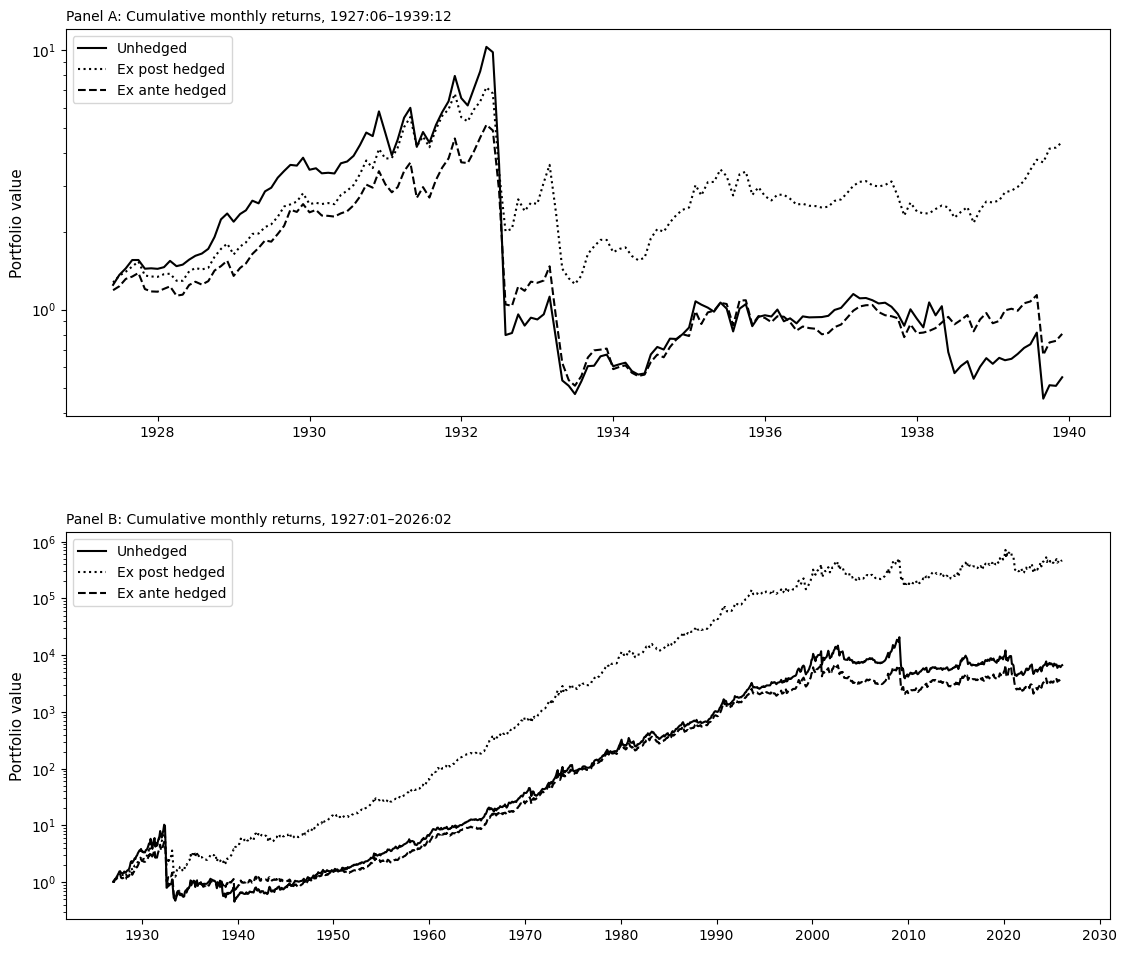

In [8]:
# Figure 4: Ex ante vs ex post hedged momentum (42-day rolling beta)

# Compute 42-day rolling betas using daily data
# For each month t:
#   Ex ante beta: cov/var from the 42 trading days before month t
#   Ex post beta:  cov/var from the 42 trading days starting at month t
# Then hedge the monthly WML return: hedged_t = WML_t - beta_t * Mkt_t

# Daily WML and market (already loaded in data_d from cell above)
data_d_sorted = data_d.sort_index() if 'data_d' not in dir() else data_d
# Reload daily data if not available from earlier cells
try:
    _ = data_d.index[0]
except:
    mom_d = pd.read_csv('data/10_Portfolios_Prior_12_2_Daily.csv',
                        skiprows=9, index_col=0, header=0)
    mom_d.index = mom_d.index.astype(str).str.strip()
    mom_d = mom_d[mom_d.index.str.match(r'^\d{8}$')]
    mom_d.index = pd.to_datetime(mom_d.index, format='%Y%m%d')
    mom_d.columns = [f'D{i}' for i in range(1, 11)]
    mom_d = mom_d.apply(pd.to_numeric, errors='coerce').replace([-99.99, -999], np.nan) / 100
    ff_d = pd.read_csv('data/F-F_Research_Data_Factors_daily.csv', skiprows=4, index_col=0)
    ff_d.index = ff_d.index.astype(str).str.strip()
    ff_d = ff_d[ff_d.index.str.match(r'^\d{8}$')]
    ff_d.index = pd.to_datetime(ff_d.index, format='%Y%m%d')
    ff_d = ff_d.apply(pd.to_numeric, errors='coerce') / 100
    data_d = mom_d.join(ff_d, how='inner').sort_index()
    data_d['WML'] = data_d['D10'] - data_d['D1']

wml_daily = data_d['WML'].values
mkt_daily = data_d['Mkt-RF'].values
daily_dates = data_d.index

# Monthly arrays
monthly_dates = data_m.index
wml_m = data_m['WML'].values
mkt_m = data_m['Mkt-RF'].values
n_m = len(monthly_dates)

# Compute 42-day betas for each month
beta_exante_42 = np.full(n_m, np.nan)
beta_expost_42 = np.full(n_m, np.nan)

for i, mdate in enumerate(monthly_dates):
    d_idx = daily_dates.searchsorted(mdate)
    # Ex ante: 42 trading days before month t
    s, e = max(0, d_idx - 42), d_idx
    if e - s >= 20:
        w, m = wml_daily[s:e], mkt_daily[s:e]
        ok = ~(np.isnan(w) | np.isnan(m))
        if ok.sum() >= 20:
            beta_exante_42[i] = np.cov(w[ok], m[ok])[0,1] / np.var(m[ok], ddof=1)
    # Ex post: 42 trading days from start of month t
    s2, e2 = d_idx, min(len(daily_dates), d_idx + 42)
    if e2 - s2 >= 20:
        w2, m2 = wml_daily[s2:e2], mkt_daily[s2:e2]
        ok2 = ~(np.isnan(w2) | np.isnan(m2))
        if ok2.sum() >= 20:
            beta_expost_42[i] = np.cov(w2[ok2], m2[ok2])[0,1] / np.var(m2[ok2], ddof=1)

# Hedged monthly returns
hedged_exante = wml_m - np.where(np.isnan(beta_exante_42), 0, beta_exante_42) * mkt_m
hedged_expost = wml_m - np.where(np.isnan(beta_expost_42), 0, beta_expost_42) * mkt_m

# Cumulative wealth
cum_wml    = np.cumprod(1 + np.nan_to_num(wml_m))
cum_exante = np.cumprod(1 + np.nan_to_num(hedged_exante))
cum_expost = np.cumprod(1 + np.nan_to_num(hedged_expost))
dates = monthly_dates

# Plot Panel A + Panel B
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Panel A: Great Depression (1927:06 – 1939:12)
mask_a = (dates >= '1927-06') & (dates <= '1939-12')
ax1.semilogy(dates[mask_a], cum_wml[mask_a],    'k-',  lw=1.5, label='Unhedged')
ax1.semilogy(dates[mask_a], cum_expost[mask_a], 'k:',  lw=1.5, label='Ex post hedged')
ax1.semilogy(dates[mask_a], cum_exante[mask_a], 'k--', lw=1.5, label='Ex ante hedged')
ax1.set_ylabel('Portfolio value', fontsize=11)
ax1.legend(loc='upper left', fontsize=10)
ax1.set_title(
    f'Panel A: Cumulative monthly returns, '
    f'{dates[mask_a][0].strftime("%Y:%m")}\u2013{dates[mask_a][-1].strftime("%Y:%m")}',
    fontsize=10, loc='left'
)
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel B: Full sample
ax2.semilogy(dates, cum_wml,    'k-',  lw=1.5, label='Unhedged')
ax2.semilogy(dates, cum_expost, 'k:',  lw=1.5, label='Ex post hedged')
ax2.semilogy(dates, cum_exante, 'k--', lw=1.5, label='Ex ante hedged')
ax2.set_ylabel('Portfolio value', fontsize=11)
ax2.legend(loc='upper left', fontsize=10)
ax2.set_title(
    f'Panel B: Cumulative monthly returns, '
    f'{dates[0].strftime("%Y:%m")}\u2013{dates[-1].strftime("%Y:%m")}',
    fontsize=10, loc='left'
)
ax2.xaxis.set_major_locator(mdates.YearLocator(10))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.subplots_adjust(hspace=0.3, left=0.08, right=0.95, top=0.95, bottom=0.06)
plt.show()


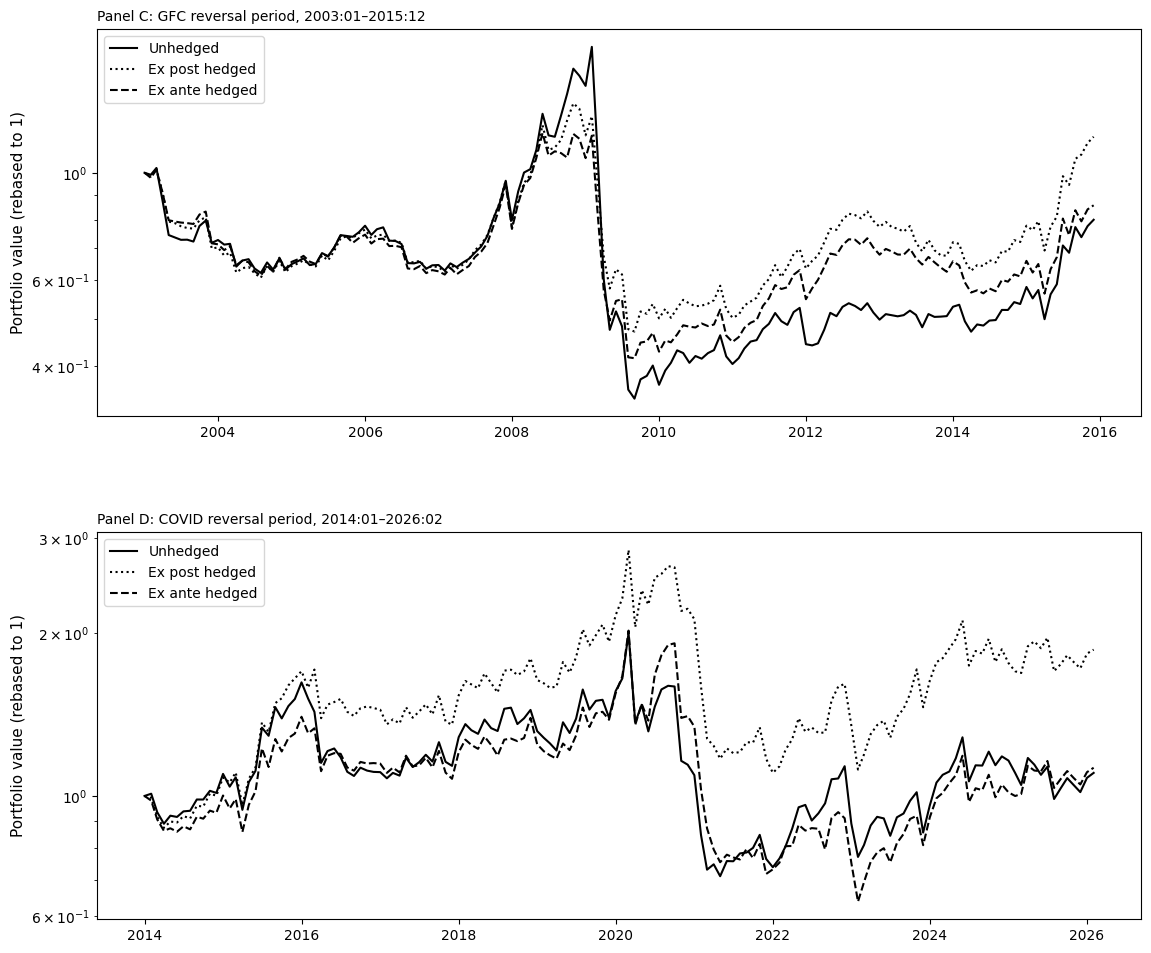

In [9]:
# Figure 4 (continued): GFC and COVID crash episodes
# Same three strategies, zoomed into ~12-year windows, rebased to 1

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Panel C: GFC period (2003–2015) 
mask_gfc = (dates >= '2003-01') & (dates <= '2015-12')
i0_gfc = np.where(mask_gfc)[0][0]
cum_wml_gfc    = cum_wml[mask_gfc]    / cum_wml[i0_gfc]
cum_expost_gfc = cum_expost[mask_gfc] / cum_expost[i0_gfc]
cum_exante_gfc = cum_exante[mask_gfc] / cum_exante[i0_gfc]

ax1.semilogy(dates[mask_gfc], cum_wml_gfc,    'k-',  lw=1.5, label='Unhedged')
ax1.semilogy(dates[mask_gfc], cum_expost_gfc, 'k:',  lw=1.5, label='Ex post hedged')
ax1.semilogy(dates[mask_gfc], cum_exante_gfc, 'k--', lw=1.5, label='Ex ante hedged')
ax1.set_ylabel('Portfolio value (rebased to 1)', fontsize=11)
ax1.legend(loc='upper left', fontsize=10)
ax1.set_title('Panel C: GFC reversal period, 2003:01\u20132015:12', fontsize=10, loc='left')
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel D: COVID period (2014–2026)
mask_covid = (dates >= '2014-01') & (dates <= '2026-12')
i0_covid = np.where(mask_covid)[0][0]
cum_wml_covid    = cum_wml[mask_covid]    / cum_wml[i0_covid]
cum_expost_covid = cum_expost[mask_covid] / cum_expost[i0_covid]
cum_exante_covid = cum_exante[mask_covid] / cum_exante[i0_covid]

ax2.semilogy(dates[mask_covid], cum_wml_covid,    'k-',  lw=1.5, label='Unhedged')
ax2.semilogy(dates[mask_covid], cum_expost_covid, 'k:',  lw=1.5, label='Ex post hedged')
ax2.semilogy(dates[mask_covid], cum_exante_covid, 'k--', lw=1.5, label='Ex ante hedged')
ax2.set_ylabel('Portfolio value (rebased to 1)', fontsize=11)
ax2.legend(loc='upper left', fontsize=10)
ax2.set_title(
    f'Panel D: COVID reversal period, 2014:01\u2013{dates[mask_covid][-1].strftime("%Y:%m")}',
    fontsize=10, loc='left'
)
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.subplots_adjust(hspace=0.3, left=0.08, right=0.95, top=0.95, bottom=0.06)
plt.show()


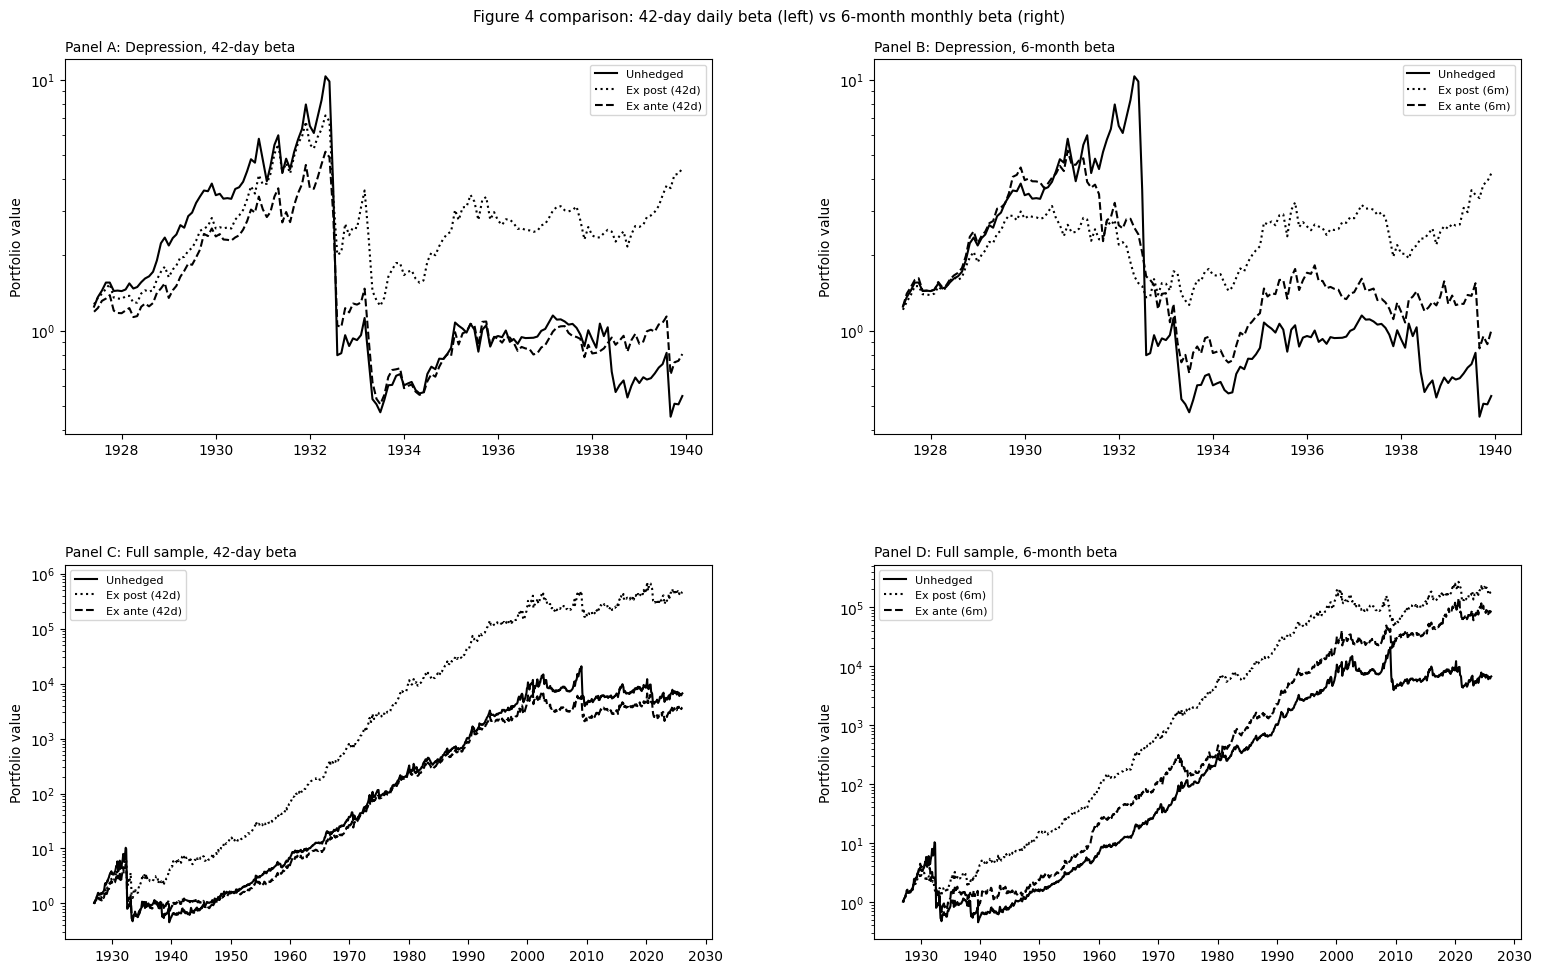

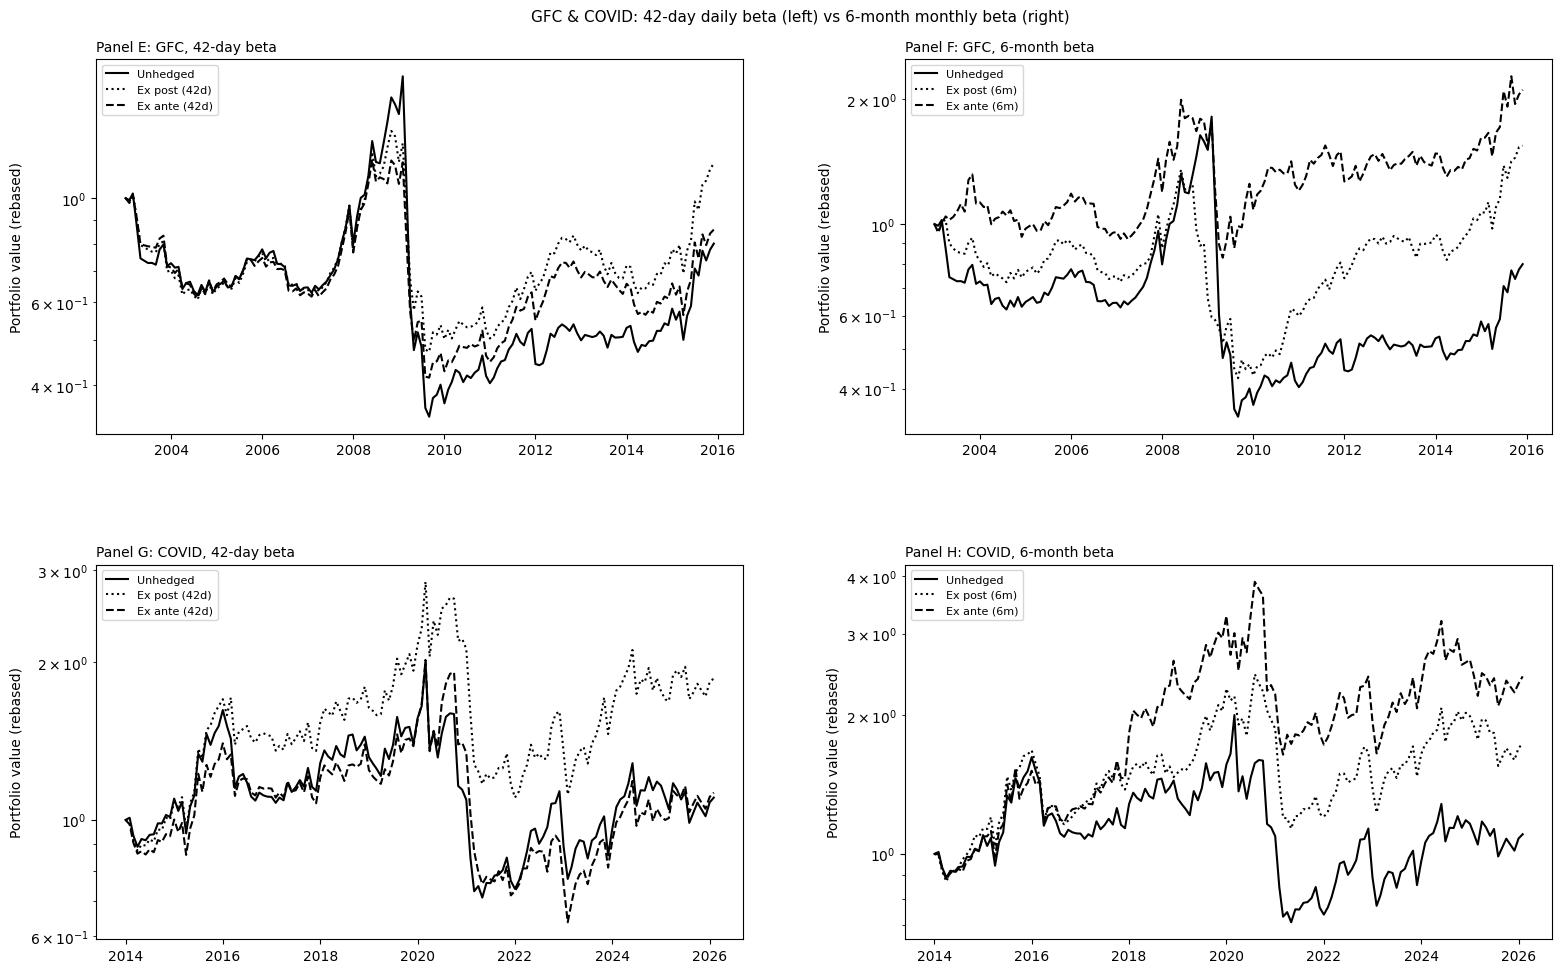

Final cumulative values:
  Unhedged:           $6,670
  Ex ante (42-day):   $3,705
  Ex post (42-day):   $468,036
  Ex ante (6-month):  $87,527
  Ex post (6-month):  $189,044


In [10]:
# Figure 4 comparison: 42-day lag vs 6-month lag
# Compute 6-month rolling betas at monthly frequency for comparison

window_6m = 6
beta_exante_6m = np.full(n_m, np.nan)
beta_expost_6m = np.full(n_m, np.nan)

for t in range(window_6m, n_m):
    w = wml_m[t-window_6m:t]; m = mkt_m[t-window_6m:t]
    ok = ~(np.isnan(w) | np.isnan(m))
    if ok.sum() >= 4:
        beta_exante_6m[t] = np.cov(w[ok], m[ok])[0,1] / np.var(m[ok], ddof=1)

for t in range(n_m - window_6m):
    w = wml_m[t:t+window_6m]; m = mkt_m[t:t+window_6m]
    ok = ~(np.isnan(w) | np.isnan(m))
    if ok.sum() >= 4:
        beta_expost_6m[t] = np.cov(w[ok], m[ok])[0,1] / np.var(m[ok], ddof=1)

hedged_exante_6m = wml_m - np.where(np.isnan(beta_exante_6m), 0, beta_exante_6m) * mkt_m
hedged_expost_6m = wml_m - np.where(np.isnan(beta_expost_6m), 0, beta_expost_6m) * mkt_m

cum_exante_6m = np.cumprod(1 + np.nan_to_num(hedged_exante_6m))
cum_expost_6m = np.cumprod(1 + np.nan_to_num(hedged_expost_6m))

# Plot: 4 panels comparing 42-day vs 6-month lag
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel A: Great Depression – 42-day lag
ax = axes[0, 0]
mask_a = (dates >= '1927-06') & (dates <= '1939-12')
ax.semilogy(dates[mask_a], cum_wml[mask_a],    'k-',  lw=1.5, label='Unhedged')
ax.semilogy(dates[mask_a], cum_expost[mask_a], 'k:',  lw=1.5, label='Ex post (42d)')
ax.semilogy(dates[mask_a], cum_exante[mask_a], 'k--', lw=1.5, label='Ex ante (42d)')
ax.set_ylabel('Portfolio value', fontsize=10)
ax.legend(loc='upper right', fontsize=8)
ax.set_title('Panel A: Depression, 42-day beta', fontsize=10, loc='left')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel B: Great Depression – 6-month lag
ax = axes[0, 1]
ax.semilogy(dates[mask_a], cum_wml[mask_a],       'k-',  lw=1.5, label='Unhedged')
ax.semilogy(dates[mask_a], cum_expost_6m[mask_a], 'k:',  lw=1.5, label='Ex post (6m)')
ax.semilogy(dates[mask_a], cum_exante_6m[mask_a], 'k--', lw=1.5, label='Ex ante (6m)')
ax.set_ylabel('Portfolio value', fontsize=10)
ax.legend(loc='upper right', fontsize=8)
ax.set_title('Panel B: Depression, 6-month beta', fontsize=10, loc='left')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel C: Full sample – 42-day lag
ax = axes[1, 0]
ax.semilogy(dates, cum_wml,    'k-',  lw=1.5, label='Unhedged')
ax.semilogy(dates, cum_expost, 'k:',  lw=1.5, label='Ex post (42d)')
ax.semilogy(dates, cum_exante, 'k--', lw=1.5, label='Ex ante (42d)')
ax.set_ylabel('Portfolio value', fontsize=10)
ax.legend(loc='upper left', fontsize=8)
ax.set_title('Panel C: Full sample, 42-day beta', fontsize=10, loc='left')
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel D: Full sample – 6-month lag
ax = axes[1, 1]
ax.semilogy(dates, cum_wml,       'k-',  lw=1.5, label='Unhedged')
ax.semilogy(dates, cum_expost_6m, 'k:',  lw=1.5, label='Ex post (6m)')
ax.semilogy(dates, cum_exante_6m, 'k--', lw=1.5, label='Ex ante (6m)')
ax.set_ylabel('Portfolio value', fontsize=10)
ax.legend(loc='upper left', fontsize=8)
ax.set_title('Panel D: Full sample, 6-month beta', fontsize=10, loc='left')
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle(
    'Figure 4 comparison: 42-day daily beta (left) vs 6-month monthly beta (right)',
    fontsize=11, y=0.99
)
fig.subplots_adjust(hspace=0.35, wspace=0.25, left=0.06, right=0.97, top=0.94, bottom=0.06)
plt.show()

# GFC and COVID comparison
fig2, axes2 = plt.subplots(2, 2, figsize=(16, 10))

# Panel E: GFC – 42-day lag
ax = axes2[0, 0]
mask_gfc = (dates >= '2003-01') & (dates <= '2015-12')
i0 = np.where(mask_gfc)[0][0]
ax.semilogy(dates[mask_gfc], cum_wml[mask_gfc]/cum_wml[i0],       'k-',  lw=1.5, label='Unhedged')
ax.semilogy(dates[mask_gfc], cum_expost[mask_gfc]/cum_expost[i0], 'k:',  lw=1.5, label='Ex post (42d)')
ax.semilogy(dates[mask_gfc], cum_exante[mask_gfc]/cum_exante[i0], 'k--', lw=1.5, label='Ex ante (42d)')
ax.set_ylabel('Portfolio value (rebased)', fontsize=10)
ax.legend(loc='upper left', fontsize=8)
ax.set_title('Panel E: GFC, 42-day beta', fontsize=10, loc='left')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel F: GFC – 6-month lag
ax = axes2[0, 1]
ax.semilogy(dates[mask_gfc], cum_wml[mask_gfc]/cum_wml[i0],             'k-',  lw=1.5, label='Unhedged')
ax.semilogy(dates[mask_gfc], cum_expost_6m[mask_gfc]/cum_expost_6m[i0], 'k:',  lw=1.5, label='Ex post (6m)')
ax.semilogy(dates[mask_gfc], cum_exante_6m[mask_gfc]/cum_exante_6m[i0], 'k--', lw=1.5, label='Ex ante (6m)')
ax.set_ylabel('Portfolio value (rebased)', fontsize=10)
ax.legend(loc='upper left', fontsize=8)
ax.set_title('Panel F: GFC, 6-month beta', fontsize=10, loc='left')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel G: COVID – 42-day lag
ax = axes2[1, 0]
mask_covid = (dates >= '2014-01') & (dates <= '2026-12')
i0c = np.where(mask_covid)[0][0]
ax.semilogy(dates[mask_covid], cum_wml[mask_covid]/cum_wml[i0c],       'k-',  lw=1.5, label='Unhedged')
ax.semilogy(dates[mask_covid], cum_expost[mask_covid]/cum_expost[i0c], 'k:',  lw=1.5, label='Ex post (42d)')
ax.semilogy(dates[mask_covid], cum_exante[mask_covid]/cum_exante[i0c], 'k--', lw=1.5, label='Ex ante (42d)')
ax.set_ylabel('Portfolio value (rebased)', fontsize=10)
ax.legend(loc='upper left', fontsize=8)
ax.set_title('Panel G: COVID, 42-day beta', fontsize=10, loc='left')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel H: COVID – 6-month lag
ax = axes2[1, 1]
ax.semilogy(dates[mask_covid], cum_wml[mask_covid]/cum_wml[i0c],             'k-',  lw=1.5, label='Unhedged')
ax.semilogy(dates[mask_covid], cum_expost_6m[mask_covid]/cum_expost_6m[i0c], 'k:',  lw=1.5, label='Ex post (6m)')
ax.semilogy(dates[mask_covid], cum_exante_6m[mask_covid]/cum_exante_6m[i0c], 'k--', lw=1.5, label='Ex ante (6m)')
ax.set_ylabel('Portfolio value (rebased)', fontsize=10)
ax.legend(loc='upper left', fontsize=8)
ax.set_title('Panel H: COVID, 6-month beta', fontsize=10, loc='left')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig2.suptitle(
    'GFC & COVID: 42-day daily beta (left) vs 6-month monthly beta (right)',
    fontsize=11, y=0.99
)
fig2.subplots_adjust(hspace=0.35, wspace=0.25, left=0.06, right=0.97, top=0.94, bottom=0.06)
plt.show()

# Summary stats
print(f'Final cumulative values:')
print(f'  Unhedged:           ${cum_wml[-1]:,.0f}')
print(f'  Ex ante (42-day):   ${cum_exante[-1]:,.0f}')
print(f'  Ex post (42-day):   ${cum_expost[-1]:,.0f}')
print(f'  Ex ante (6-month):  ${cum_exante_6m[-1]:,.0f}')
print(f'  Ex post (6-month):  ${cum_expost_6m[-1]:,.0f}')


## Table 5 – Momentum Returns and Estimated Market Variance

Replication of Daniel & Moskowitz (2016), Table 5. The regression specification is:

$$\tilde{R}_{\text{WML},t} = \hat{\gamma}_0 + \hat{\gamma}_B \cdot I_{B,t-1} + \hat{\gamma}_{\sigma^2} \cdot \hat{\sigma}^2_{m,t-1} + \hat{\gamma}_{\text{int}} \cdot I_{B,t-1} \cdot \hat{\sigma}^2_{m,t-1} + \tilde{\epsilon}_t$$

### Variable definitions

| Symbol | Definition |
|--------|------------|
| $I_{B,t-1}$ | Bear-market indicator (1 if 24-month cumulative market return < 0) |
| $\hat{\sigma}^2_{m,t-1}$ | Annualized variance of daily market returns over the 126 trading days preceding month $t$ (= daily variance × 252) |
| $\hat{\gamma}_0, \hat{\gamma}_B$ | Intercepts (×100, in % per month) |
| $\hat{\gamma}_{\sigma^2}$ | Sensitivity to market variance |
| $\hat{\gamma}_{\text{int}}$ | Interaction: bear × variance |

All $t$-statistics use Newey-West standard errors with 6 lags.


In [11]:
# Table 5: Momentum returns and estimated market variance

# Compute annualized market variance (126-day rolling, ×252)
daily_mkt_t5 = data_d['Mkt-RF']
daily_dates_t5 = data_d.index

sigma2_ann = np.full(len(data_m), np.nan)
for i, mdate in enumerate(data_m.index):
    d_idx = daily_dates_t5.searchsorted(mdate)
    s = max(0, d_idx - 126)
    if d_idx - s >= 60:
        vals = daily_mkt_t5.iloc[s:d_idx].dropna().values
        if len(vals) >= 60:
            sigma2_ann[i] = np.var(vals, ddof=1) * 252  # annualize

data_m['sigma2'] = sigma2_ann
data_m['I_B_sigma2'] = data_m['I_B'] * data_m['sigma2']

# NW OLS helper
def nw_ols_t5(y_arr, X_arr, lags=6):
    mask = ~(np.isnan(y_arr) | np.any(np.isnan(X_arr), axis=1))
    y, X = y_arr[mask], X_arr[mask]
    n = len(y)
    Xd = np.column_stack([np.ones(n), X])
    b = np.linalg.lstsq(Xd, y, rcond=None)[0]
    e = y - Xd @ b
    S = Xd.T @ np.diag(e**2) @ Xd
    for lag in range(1, lags + 1):
        G = Xd[lag:].T @ np.diag(e[lag:] * e[:-lag]) @ Xd[:-lag]
        S += (1 - lag / (lags + 1)) * (G + G.T)
    V = np.linalg.inv(Xd.T @ Xd) @ S @ np.linalg.inv(Xd.T @ Xd)
    return b, b / np.sqrt(np.diag(V))

# Five specifications
y_t5 = data_m['WML'].values
specs_t5 = [
    ('(1)', ['I_B']),
    ('(2)', ['sigma2']),
    ('(3)', ['I_B', 'sigma2']),
    ('(4)', ['I_B_sigma2']),
    ('(5)', ['I_B', 'sigma2', 'I_B_sigma2']),
]

results_t5 = {}
for name, xcols in specs_t5:
    X = data_m[xcols].values
    b, t = nw_ols_t5(y_t5, X)
    results_t5[name] = {'b': b, 't': t, 'xcols': xcols}

# Format table (alternating coef / t-stat rows)
# Coefficient map: (var_key, label, scale_by_100)
coef_map_t5 = [
    ('intercept',   r'$\hat{\gamma}_0$',              True),
    ('I_B',         r'$\hat{\gamma}_B$',              True),
    ('sigma2',      r'$\hat{\gamma}_{\sigma^2}$',     False),
    ('I_B_sigma2',  r'$\hat{\gamma}_{int}$',          False),
]

spec_names_t5 = [s[0] for s in specs_t5]
all_rows_t5 = []; idx_labels_t5 = []

for var_key, clabel, scale in coef_map_t5:
    cr = {}; tr = {}
    for sn, res in results_t5.items():
        xcols = res['xcols']; b = res['b']; t = res['t']
        if var_key == 'intercept':
            idx = 0
        elif var_key in xcols:
            idx = xcols.index(var_key) + 1
        else:
            cr[sn] = ''; tr[sn] = ''
            continue
        val = b[idx] * 100 if scale else b[idx]
        cr[sn] = f'{val:.3f}'
        tr[sn] = f'({t[idx]:.1f})'
    all_rows_t5 += [cr, tr]
    idx_labels_t5 += [(clabel, 'coef'), (clabel, 't-stat')]

midx_t5 = pd.MultiIndex.from_tuples(idx_labels_t5, names=['Coefficient', ''])
tab5 = pd.DataFrame(all_rows_t5, index=midx_t5)

start_yr = data_m.index[0].strftime('%Y:%m')
end_yr   = data_m.index[-1].strftime('%Y:%m')
print(f'Table 5 \u2013 Momentum returns and estimated market variance, {start_yr}\u2013{end_yr}')
print('gamma_0 and gamma_B x100 (% per month). t-stats (NW, 6 lags) in parentheses.')
tab5


Table 5 – Momentum returns and estimated market variance, 1927:01–2026:02
gamma_0 and gamma_B x100 (% per month). t-stats (NW, 6 lags) in parentheses.


(1)     (2)     (3)     (4)     (5)
Coefficient                                                             
$\hat{\gamma}_0$          coef     1.550   1.774   1.913   1.459   1.747
                          t-stat   (8.4)   (7.5)   (7.6)   (7.8)   (9.3)
$\hat{\gamma}_B$          coef    -2.646          -1.825          -1.137
                          t-stat  (-2.7)          (-2.4)          (-1.2)
$\hat{\gamma}_{\sigma^2}$ coef            -0.228  -0.174          -0.095
                          t-stat          (-2.4)  (-2.1)          (-2.3)
$\hat{\gamma}_{int}$      coef                            -0.306  -0.156
                          t-stat                          (-2.1)  (-0.9)

## Table 6 – WML Returns on Variance Swap Returns

Replication of Daniel & Moskowitz (2016), Table 6. Daily time-series regressions of WML on the forecasting variable $I_{B\sigma^2}$ and market/variance factors.

### Regression specification

$$\tilde{R}_{\text{WML},t} = \alpha + \gamma \cdot I_{B\sigma^2,t-1} + \beta_m \cdot \tilde{r}^e_{m,t} + \beta_{m,B} \cdot I_{B\sigma^2,t-1} \cdot \tilde{r}^e_{m,t} + \beta_{vs} \cdot \tilde{r}_{vs,t} + \beta_{vs,B} \cdot I_{B\sigma^2,t-1} \cdot \tilde{r}_{vs,t} + \epsilon_t$$

### Variable definitions

| Symbol | Definition |
|--------|------------|
| $I_{B\sigma^2,t-1}$ | $I_{B,t-1} \cdot \hat{\sigma}^2_{m,t-1}$ — bear indicator × annualized 126-day market variance |
| $\tilde{r}^e_{m,t}$ | Daily excess market return |
| $\tilde{r}_{vs,t}$ | Variance swap return, proxied by the daily pct change in VIX² implied variance: $(VIX_t^2 - VIX_{t-1}^2) / VIX_{t-1}^2$ |

The intercept $\alpha$ and the coefficient on $I_{B\sigma^2}$ are multiplied by 25,200 (= 252 × 100) to convert to annualized percentage terms.

VIX data sourced from FRED (ticker: VIXCLS). Sample period: 1990:01 onwards.


In [12]:
# Table 6: WML returns on variance swap returns (daily regression)

# Download VIX from FRED as variance swap proxy
import pandas_datareader.data as web
import datetime

vix_raw = web.DataReader('VIXCLS', 'fred', datetime.datetime(1990, 1, 1))
vix_raw = vix_raw.dropna()
# VIX is annualized implied vol in %. Implied variance = (VIX/100)^2
# Variance swap return ≈ pct change in implied variance
impl_var = (vix_raw['VIXCLS'] / 100) ** 2
r_vs_vix = impl_var.pct_change()
r_vs_vix.name = 'r_vs'

# Construct daily variables
# Bear indicator: trailing 504 trading days (~2 years)
mkt_total_t6 = data_d['Mkt-RF'] + data_d['RF']
cum_504_t6 = (1 + mkt_total_t6).rolling(504).apply(np.prod, raw=True).shift(1) - 1
data_d['I_B_t6'] = (cum_504_t6 < 0).astype(float)

# Annualized trailing 126-day market variance
data_d['sigma2_t6'] = data_d['Mkt-RF'].rolling(126).var(ddof=1).shift(1) * 252

# I_{B*sigma2}
data_d['I_Bsig2_t6'] = data_d['I_B_t6'] * data_d['sigma2_t6']

# Market excess return
data_d['Rm_t6'] = data_d['Mkt-RF']

# Merge VIX-based variance swap return
data_d['r_vs_t6'] = r_vs_vix.reindex(data_d.index)

# Interactions
data_d['I_Bsig2_Rm_t6']  = data_d['I_Bsig2_t6'] * data_d['Rm_t6']
data_d['I_Bsig2_rvs_t6'] = data_d['I_Bsig2_t6'] * data_d['r_vs_t6']

# Sample from 1990
sample_t6 = data_d['1990-01-02':].copy()

# NW OLS (daily, 10 lags)
def nw_ols_t6(y_arr, X_arr, lags=10):
    mask = ~(np.isnan(y_arr) | np.any(np.isnan(X_arr), axis=1))
    y, X = y_arr[mask], X_arr[mask]
    n = len(y)
    Xd = np.column_stack([np.ones(n), X])
    b = np.linalg.lstsq(Xd, y, rcond=None)[0]
    e = y - Xd @ b
    S = Xd.T @ np.diag(e**2) @ Xd
    for lag in range(1, lags + 1):
        G = Xd[lag:].T @ np.diag(e[lag:] * e[:-lag]) @ Xd[:-lag]
        S += (1 - lag / (lags + 1)) * (G + G.T)
    V = np.linalg.inv(Xd.T @ Xd) @ S @ np.linalg.inv(Xd.T @ Xd)
    return b, b / np.sqrt(np.diag(V))

# Three specifications
y_t6 = sample_t6['WML'].values
specs_t6 = [
    ('(1)', ['I_Bsig2_t6']),
    ('(2)', ['I_Bsig2_t6', 'Rm_t6', 'I_Bsig2_Rm_t6']),
    ('(3)', ['I_Bsig2_t6', 'Rm_t6', 'I_Bsig2_Rm_t6', 'r_vs_t6', 'I_Bsig2_rvs_t6']),
]

results_t6 = {}
for name, xcols in specs_t6:
    X = sample_t6[xcols].values
    b, t = nw_ols_t6(y_t6, X)
    results_t6[name] = {'b': b, 't': t, 'xcols': xcols}

# Format table
# alpha and I_Bsig2 scaled by 25200 (annualized %); others as-is
coef_map_t6 = [
    ('intercept', r'$\alpha$', True),
    ('I_Bsig2_t6', r'$I_{B\sigma^2}$', True),
    ('Rm_t6', r'$\tilde{r}^e_{m,t}$', False),
    ('I_Bsig2_Rm_t6', r'$I_{B\sigma^2} \cdot \tilde{r}^e_{m,t}$', False),
    ('r_vs_t6', r'$\tilde{r}_{vs,t}$', False),
    ('I_Bsig2_rvs_t6', r'$I_{B\sigma^2} \cdot \tilde{r}_{vs,t}$', False),
]

all_rows_t6 = []; idx_labels_t6 = []
for var_key, clabel, scale in coef_map_t6:
    cr = {}; tr = {}
    for sn, res in results_t6.items():
        xcols = res['xcols']; b = res['b']; t = res['t']
        if var_key == 'intercept':
            idx = 0
        elif var_key in xcols:
            idx = xcols.index(var_key) + 1
        else:
            cr[sn] = ''; tr[sn] = ''
            continue
        val = b[idx] * 25200 if scale else b[idx]
        cr[sn] = f'{val:.2f}'
        tr[sn] = f'({t[idx]:.1f})'
    all_rows_t6 += [cr, tr]
    idx_labels_t6 += [(clabel, 'coef'), (clabel, 't-stat')]

midx_t6 = pd.MultiIndex.from_tuples(idx_labels_t6, names=['Independent variable', ''])
tab6 = pd.DataFrame(all_rows_t6, index=midx_t6)

start_d = sample_t6.index[0].strftime('%Y-%m-%d')
end_d   = sample_t6.index[-1].strftime('%Y-%m-%d')
print(f'Table 6 \u2013 WML on variance swap returns, {start_d} to {end_d}')
print('alpha and I_Bsig2 x25200 (annualized %). t-stats (NW, 10 lags) in parentheses.')
print(f'Variance swap return proxied by VIX implied variance pct change (FRED: VIXCLS).')
tab6


Table 6 – WML on variance swap returns, 1990-01-02 to 2026-02-27
alpha and I_Bsig2 x25200 (annualized %). t-stats (NW, 10 lags) in parentheses.
Variance swap return proxied by VIX implied variance pct change (FRED: VIXCLS).


(1)      (2)      (3)
Independent variable                                                     
$\alpha$                                coef       5.96     5.27     9.10
                                        t-stat    (1.6)    (1.4)    (2.5)
$I_{B\sigma^2}$                         coef    -444.20  -390.03  -406.46
                                        t-stat   (-2.3)   (-2.4)   (-2.4)
$\tilde{r}^e_{m,t}$                     coef                0.02    -0.09
                                        t-stat             (0.8)   (-2.1)
$I_{B\sigma^2} \cdot \tilde{r}^e_{m,t}$ coef               -2.00    -1.26
                                        t-stat            (-6.1)   (-3.2)
$\tilde{r}_{vs,t}$                      coef                        -0.01
                                        t-stat                     (-5.5)
$I_{B\sigma^2} \cdot \tilde{r}_{vs,t}$  coef                         0.12
                                        t-stat                      (1.8)